![lab](/Users/nov/Documents/NSU2026/DSP/Task2/lab2.png)

# Imports

In [1]:
!pip install matplotlib numpy scipy


[notice] A new release of pip available: 22.2.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import math as m
import numpy as np
import matplotlib.pyplot as plt

# Определим авторскую функцию, производящую преобразование Фурье - DFT_slow()

In [42]:
def DFT_slow(x):
    """Compute the discrete Fourier Transform of 1D array x"""
    x = np.asarray(x, dtype=float)
    N = x.shape[0]
    n = np.arange(N)
    k = n.reshape((N, 1))
    M = np.exp(-2j * np.pi * k * n / N)
    return np.dot(M, x)

# 1. Исследуем комбинированный сигнал COS с частотой 150 и 50 герц

## Сгенерируем комбинированный сигнал COS с частотой 150 и 50 герц

In [43]:
def cos_50(x):
    freq = 50
    w = 2 * m.pi * freq
    return np.cos(w * x)

def cos_150(x):
    freq = 150
    w = 2 * m.pi * freq
    return np.cos(w * x)

/var/folders/l5/1_g08l313298yj0kplr9hs7r0000gn/T/ipykernel_5308/1335089337.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend()


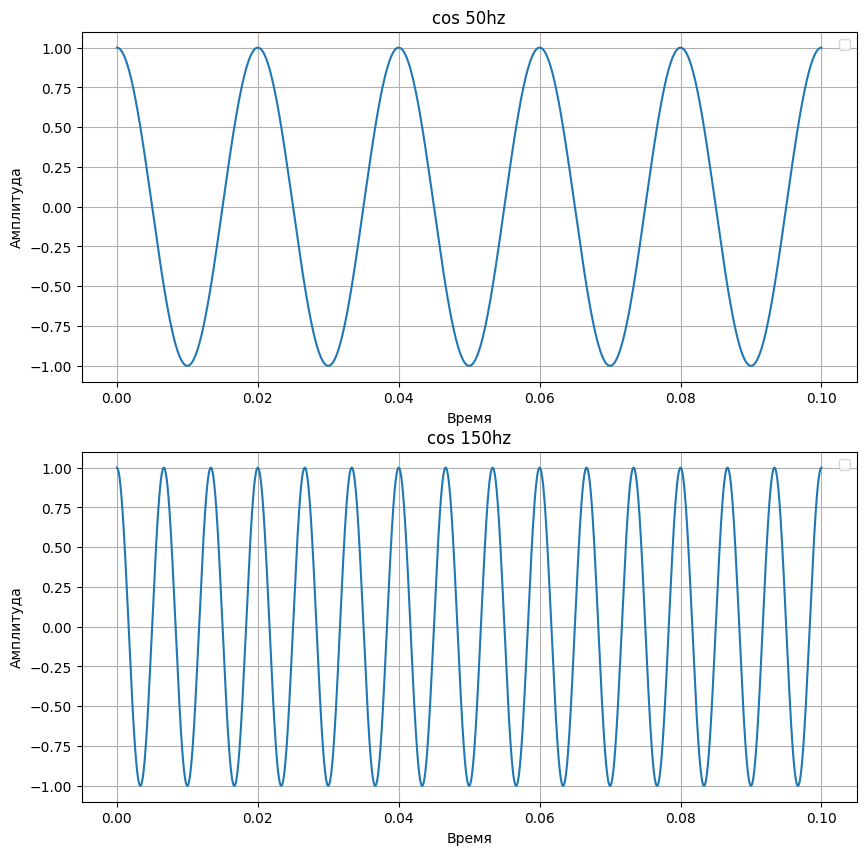

In [44]:
N = 20000
X = np.linspace(0, 1/10, N)

x_cos50 = cos_50(X)
x_cos150 = cos_150(X)


fig, axes = plt.subplots(2, 1, figsize=(10, 10))
axes[0].plot(X, x_cos50)
axes[0].set_title("cos 50hz")

axes[1].plot(X, x_cos150)
axes[1].set_title("cos 150hz")

for axis in axes:
    axis.grid(True)
    axis.legend()
    axis.set(ylabel="Амплитуда", xlabel="Время")

## Комбинируем сигналы

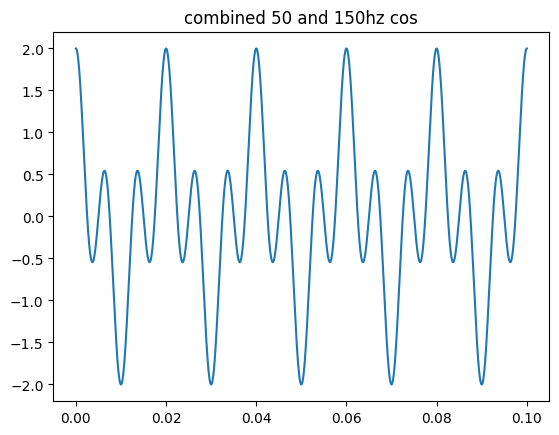

In [45]:
x_comb = x_cos50 + x_cos150

plt.plot(X, x_comb)
plt.title("combined 50 and 150hz cos")
plt.show()

## (A) ---- Построим спектр сигнала с использованием fft() и DFT_slow(). Сравним время выполнения.

### FFT() и DFT_slow()

In [46]:
dt = X[1] - X[0]

y_comb = np.fft.fft(x_comb)
# y_comb_slow = DFT_slow(x_comb)

freqs = np.fft.fftfreq(N, dt)




In [47]:
y_comb.shape

(20000,)

In [48]:
y_comb_slow.shape

(20000,)

In [49]:
# %timeit DFT_slow(x_comb)
# %timeit np.fft.fft(x_comb)

/Users/nov/Documents/NSU2026/DSP/Task2/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/var/folders/l5/1_g08l313298yj0kplr9hs7r0000gn/T/ipykernel_5308/1916240634.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend()


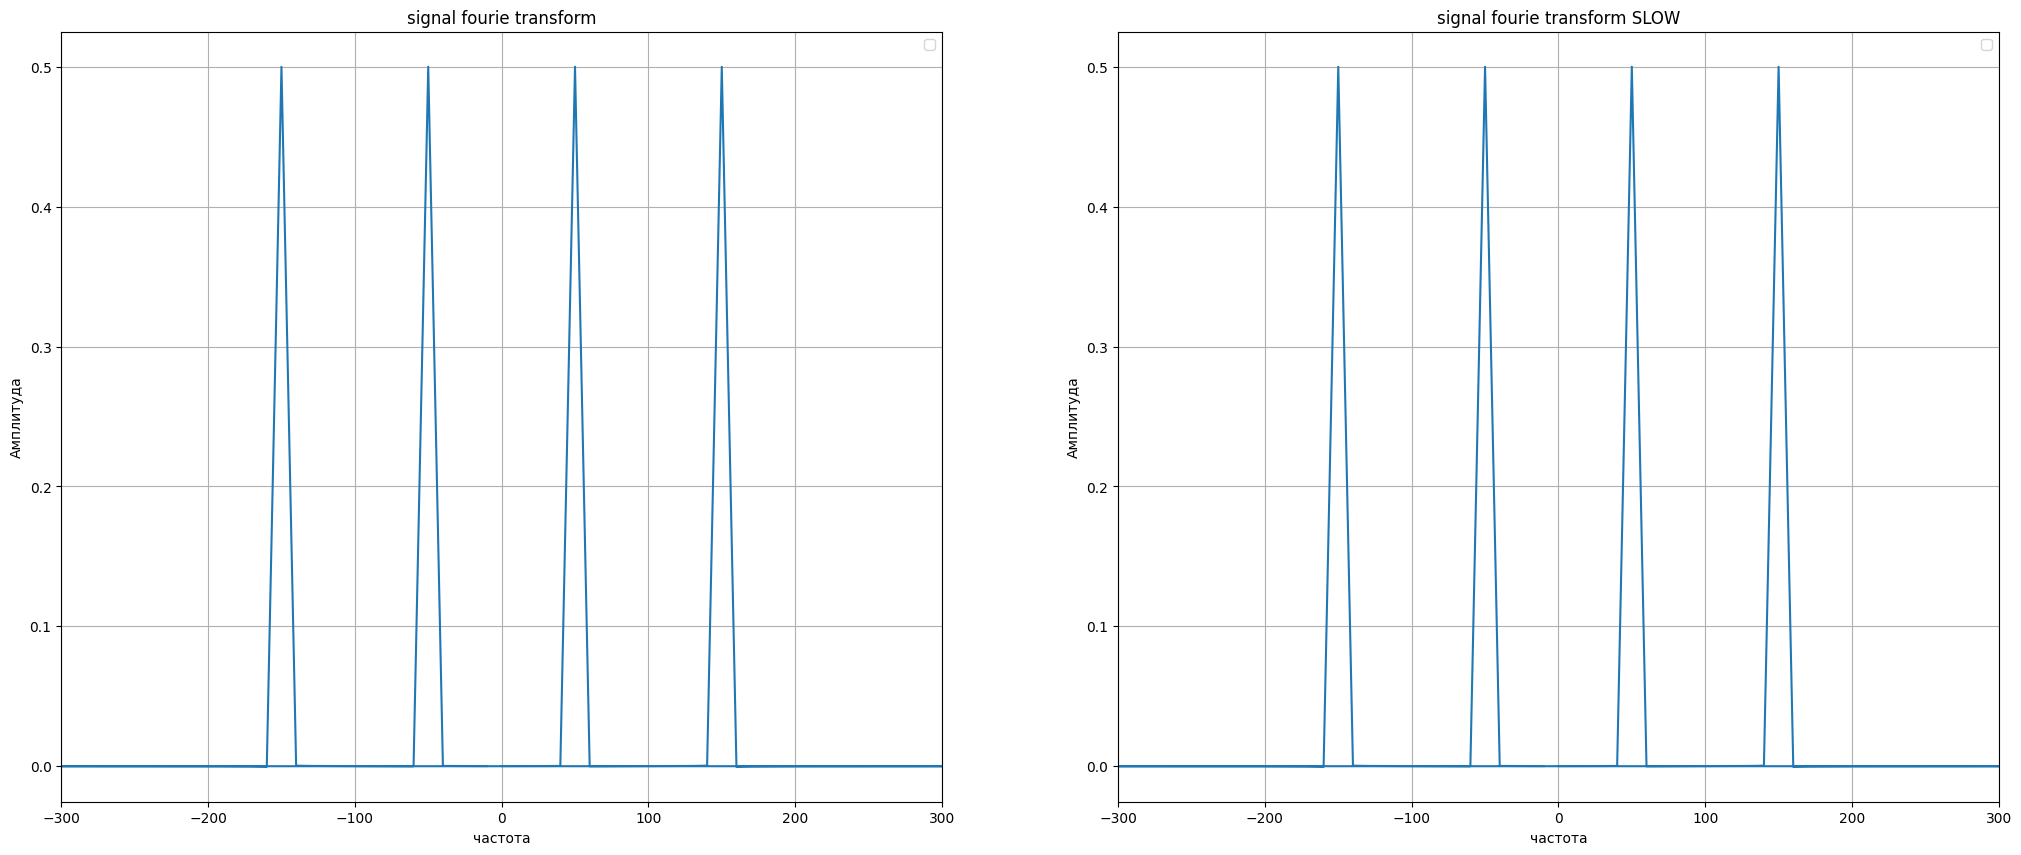

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(25, 10))
axes[0].plot(freqs, y_comb.real / N)
axes[0].set_title("signal fourie transform")
axes[0].set(ylabel="Амплитуда", xlabel="частота")
axes[0].set_xlim(-300, 300)

axes[1].plot(freqs, y_comb_slow / N)
axes[1].set_title("signal fourie transform SLOW")
axes[1].set(ylabel="Амплитуда", xlabel="частота")
axes[1].set_xlim(-300, 300)

for axis in axes:
    axis.grid(True)
    axis.legend()


## (Б) ---- Используем ifft(), чтобы вернуть сигнал в исходное состояние

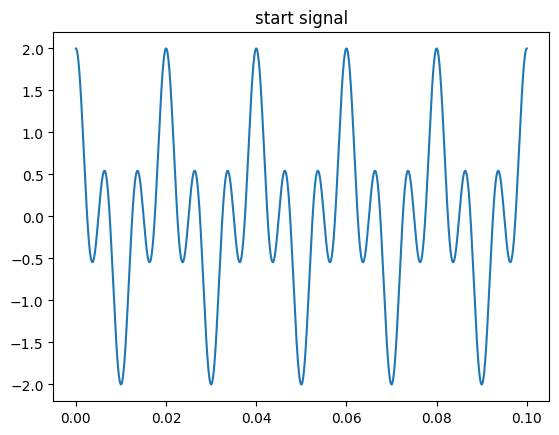

In [51]:
old_signal = np.fft.ifft(y_comb)
plt.plot(X, old_signal)
plt.title("start signal")
plt.show()

## (В) ---- Исказим сигнал белым шумом и выполним те же операции

###  Функция шума

In [52]:
def noise(x):
    return x + np.random.normal(0, 1, x.shape)

### Шумим

In [53]:
signal_noisy = noise(old_signal)

### Посмотрим на искаженный сигнал

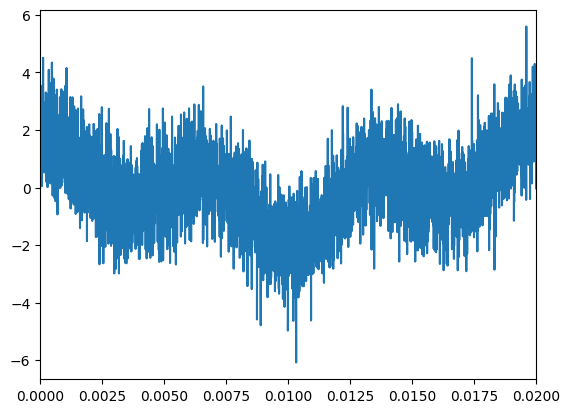

In [54]:
plt.plot(X, signal_noisy)
plt.xlim(0, 0.02)
plt.show()

### Делаем преобразование Фурье и обратное преобразование Фурье

/Users/nov/Documents/NSU2026/DSP/Task2/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/nov/Documents/NSU2026/DSP/Task2/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(0.0, 0.02)

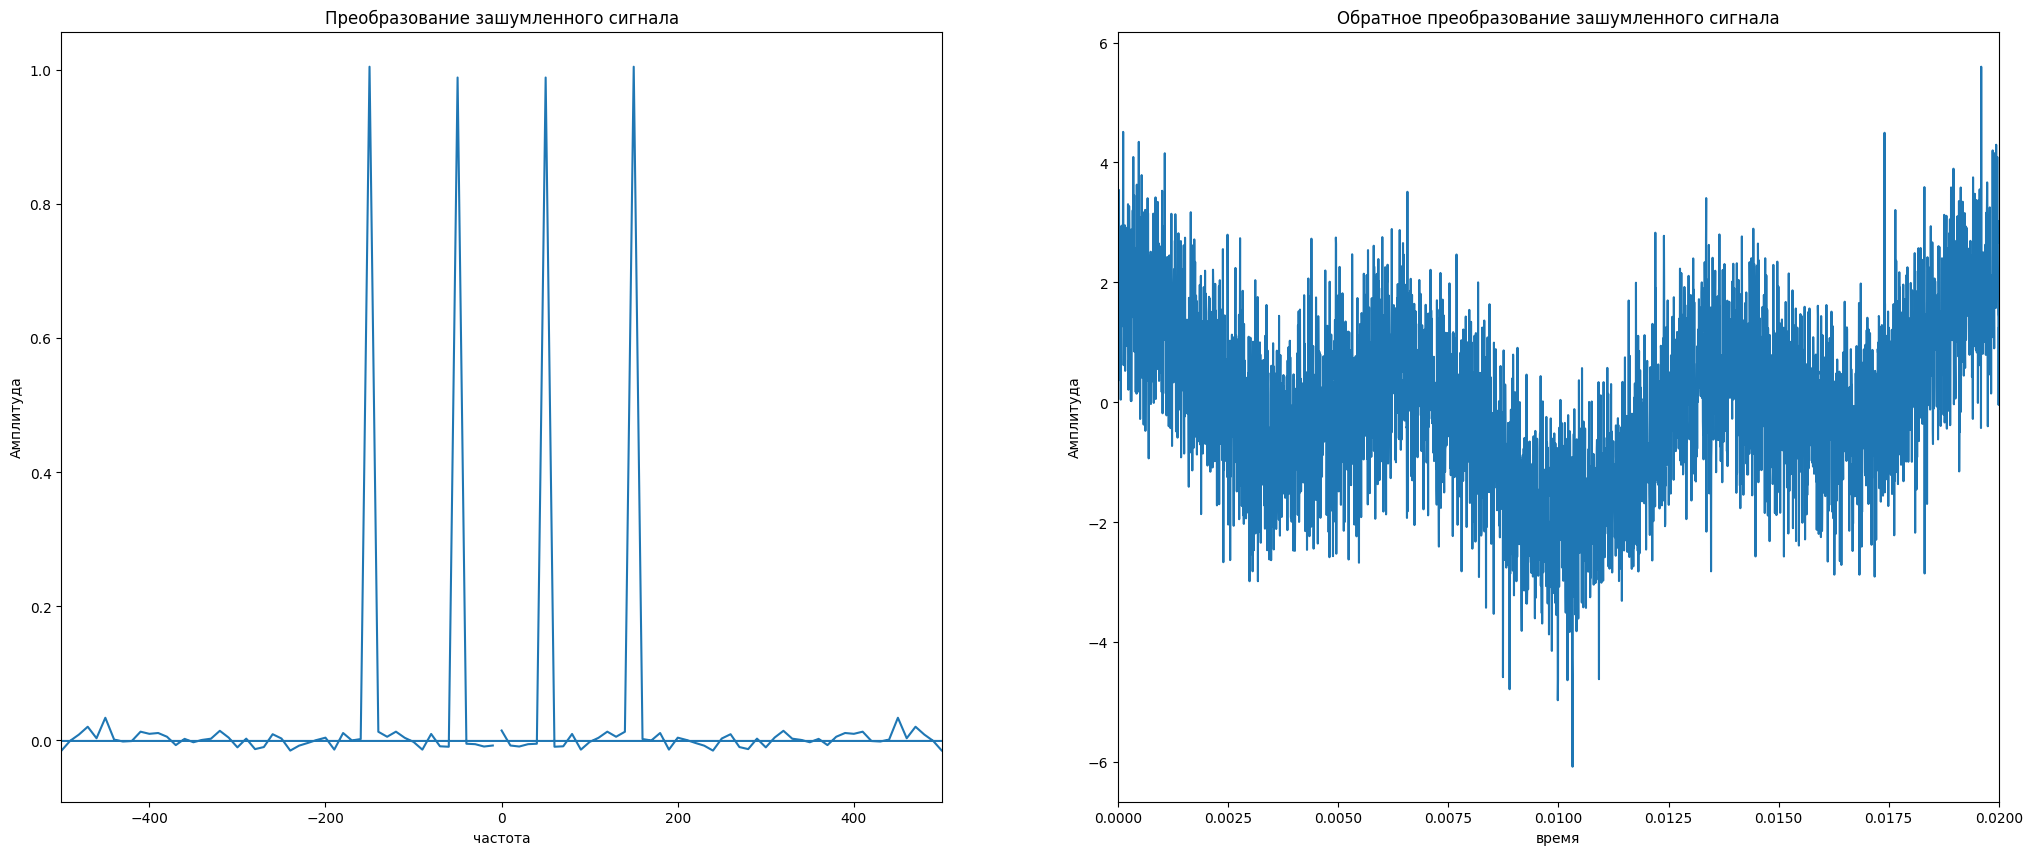

In [56]:
signal_noisy_fourie = np.fft.fft(signal_noisy)
signal_noisy_ifourie = np.fft.ifft(signal_noisy_fourie)

fig, axes = plt.subplots(1, 2, figsize=(25, 10))
axes[0].plot(freqs, signal_noisy_fourie / N * 2)
axes[0].set_title("Преобразование зашумленного сигнала")
axes[0].set(ylabel="Амплитуда", xlabel="частота")
axes[0].set_xlim(-500, 500)

axes[1].plot(X, signal_noisy_ifourie)
axes[1].set_title("Обратное преобразование зашумленного сигнала")
axes[1].set(ylabel="Амплитуда", xlabel="время")
axes[1].set_xlim(0, 0.02)




### Сравним исходный сигнал и обратно преобразованный

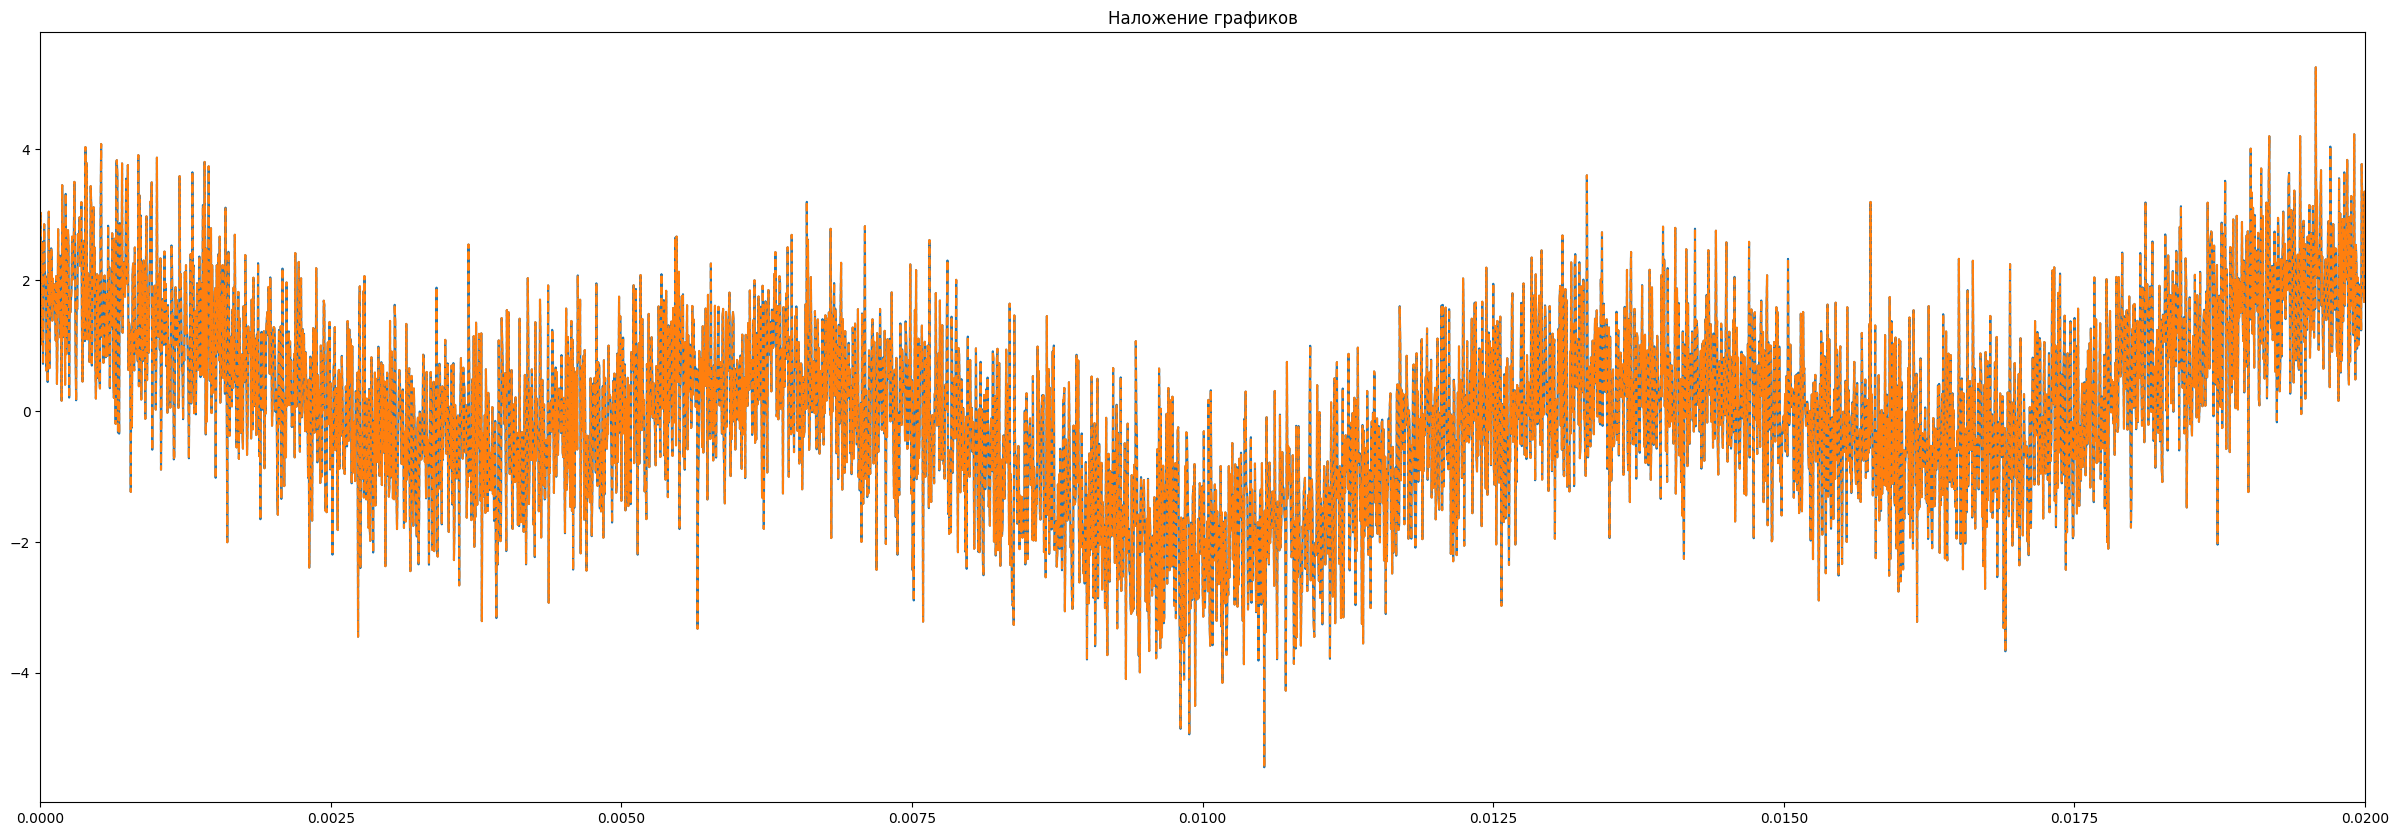

(0.0, 0.02)

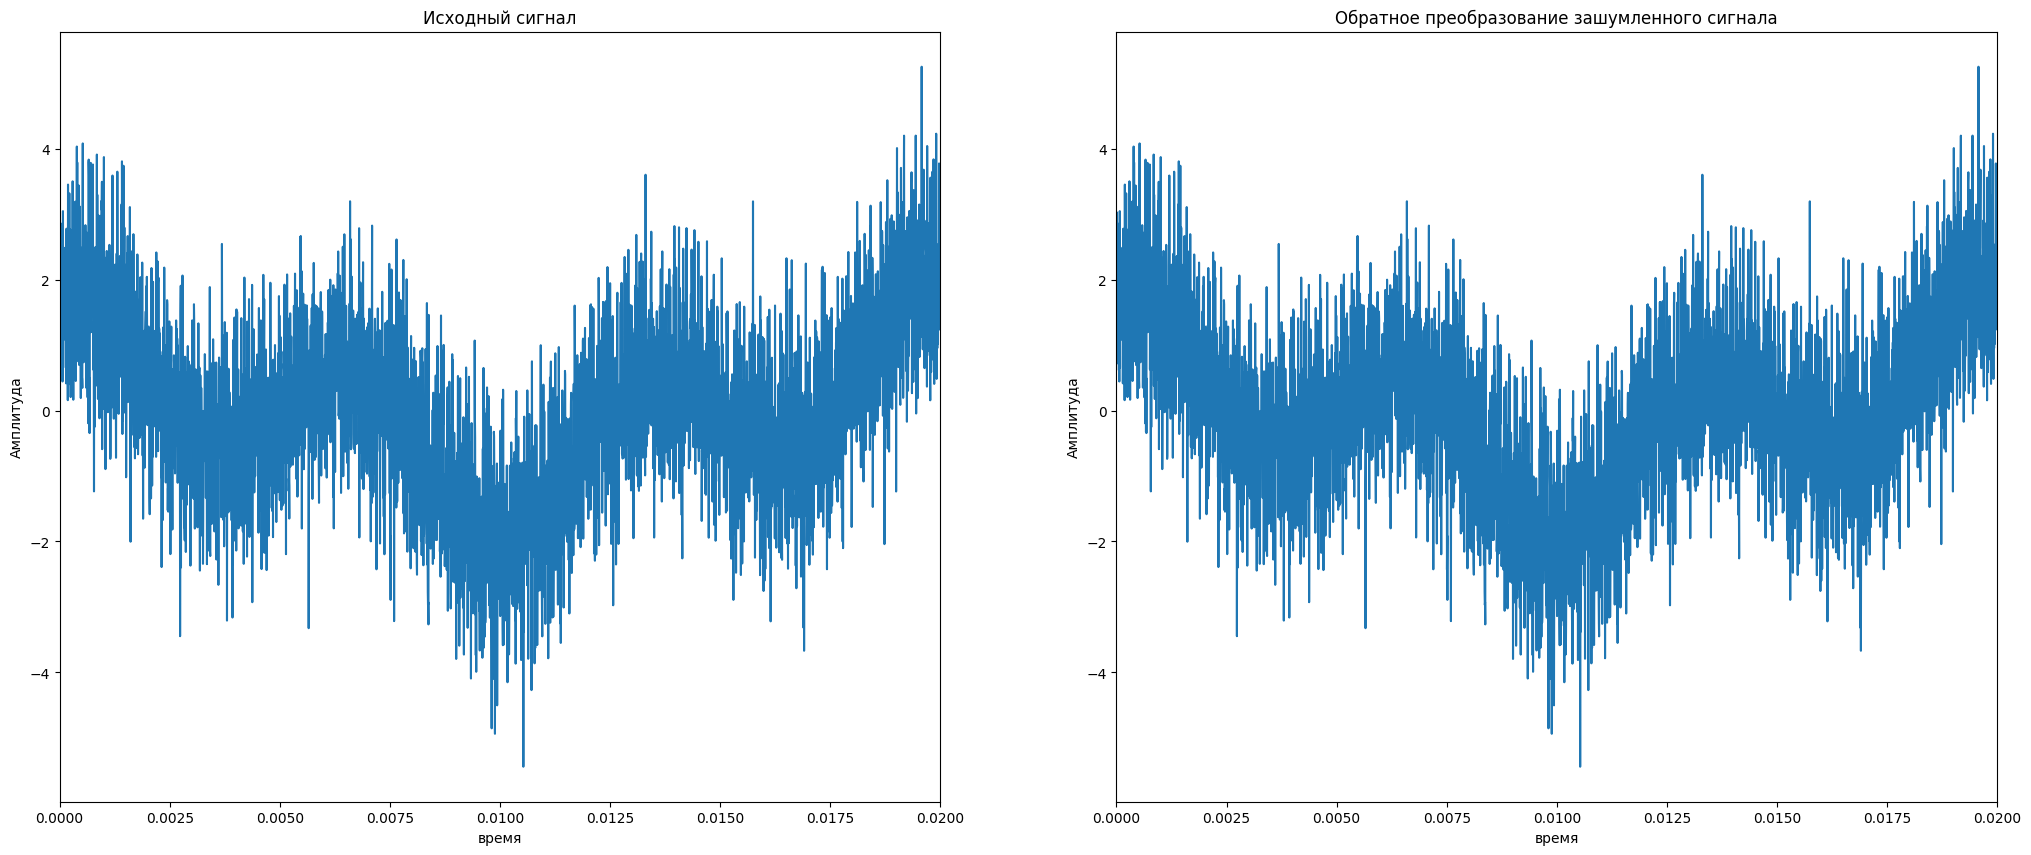

In [17]:

plt.figure(figsize=(30, 10))
plt.plot(X, signal_noisy)
plt.plot(X, signal_noisy_ifourie, "--")
plt.xlim(0, 0.02)
plt.title("Наложение графиков")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(25, 10))
axes[0].plot(X, signal_noisy)
axes[0].set_title("Исходный сигнал")
axes[0].set(ylabel="Амплитуда", xlabel="время")
axes[0].set_xlim(0, 0.02)

axes[1].plot(X, signal_noisy_ifourie)
axes[1].set_title("Обратное преобразование зашумленного сигнала")
axes[1].set(ylabel="Амплитуда", xlabel="время")
axes[1].set_xlim(0, 0.02)

# 2. Сгенерируем меандр и исследуем его

## Генерация сигнала

In [18]:
def meandr(x, T, A):
    if x % T < T // 2:
        return A
    else:
        return 0

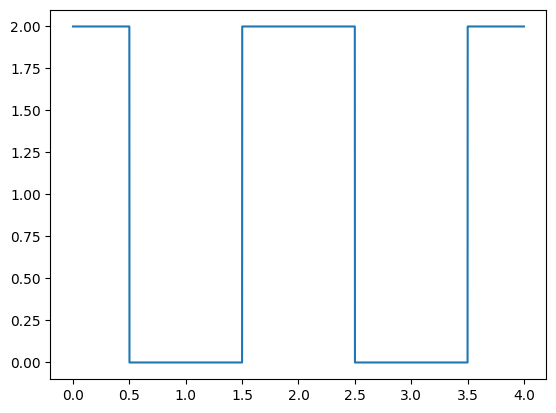

In [19]:
T = 2
A = 2
N = 10000

X = np.linspace(0, 4, N)
signal = (1 + np.sign(np.cos(2 * np.pi * X * 1/2)))

plt.plot(X, signal)

## Дискретный спектр Фурье


### Как сделал я

In [20]:
dt = X[1] - X[0]

signal_fourie = np.fft.fft(signal)
signal_fourie_slow = DFT_slow(signal)

freqs = np.fft.fftfreq(N, dt)


/var/folders/l5/1_g08l313298yj0kplr9hs7r0000gn/T/ipykernel_5308/306833379.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend()


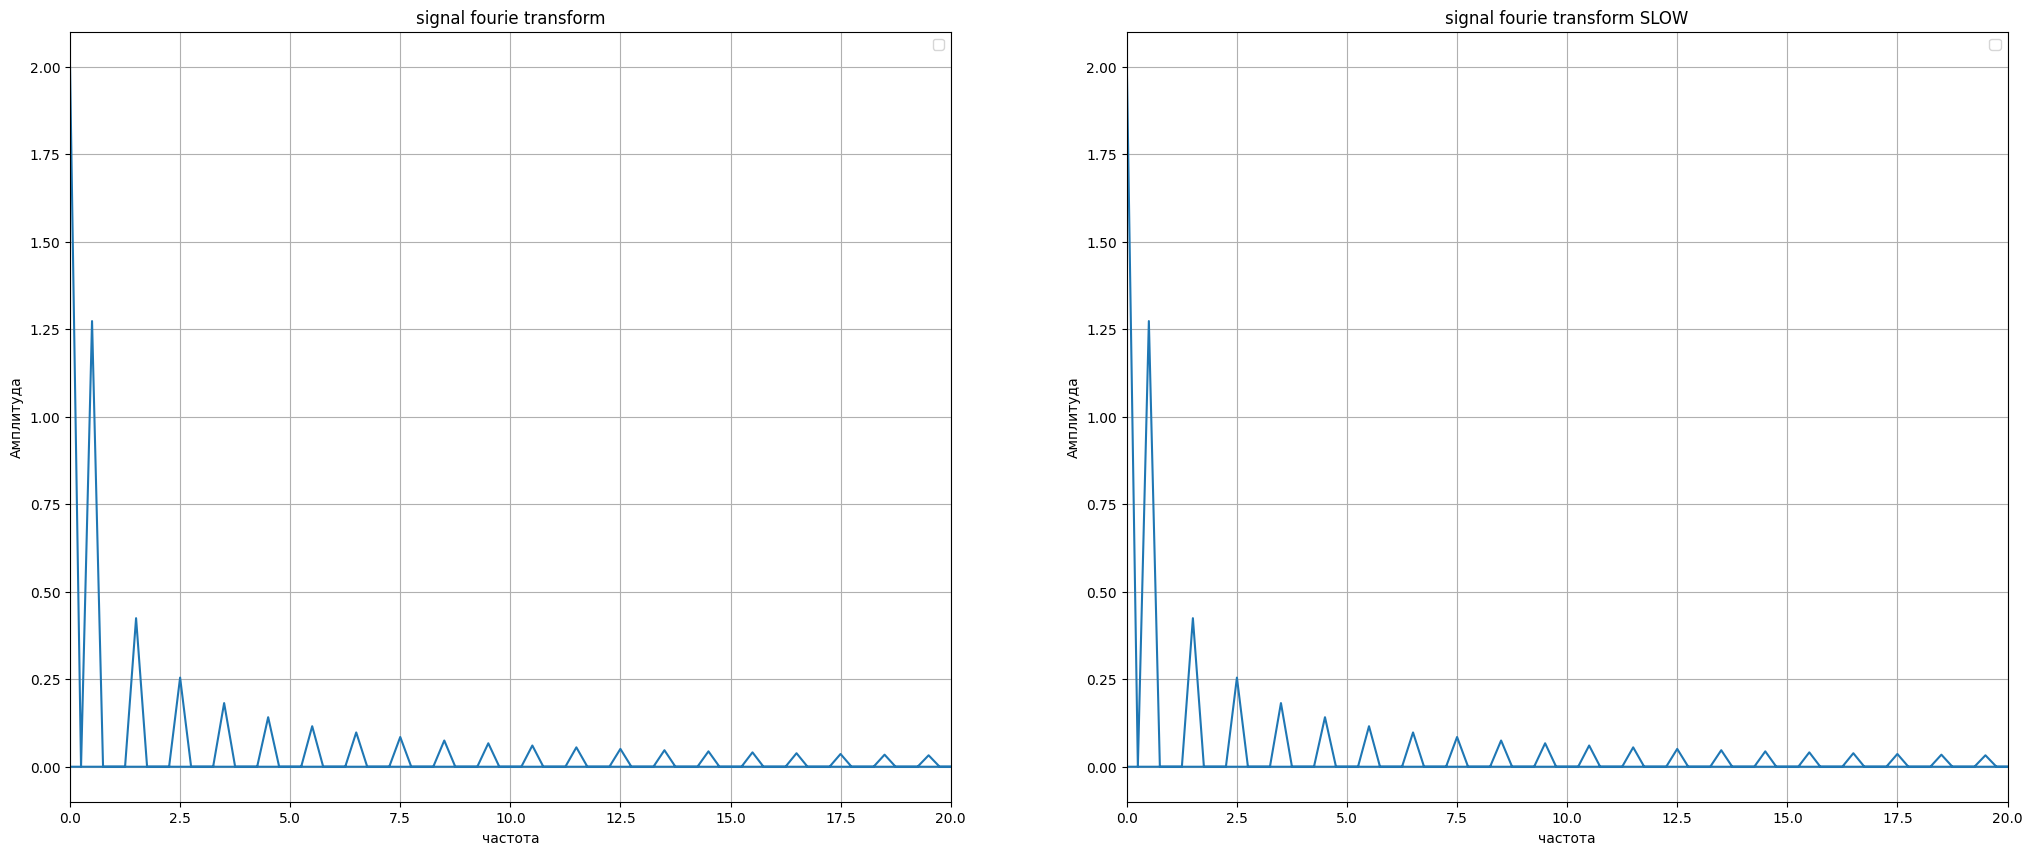

In [21]:
bound = 20


fig, axes = plt.subplots(1, 2, figsize=(25, 10))
axes[0].plot(freqs, abs(signal_fourie) / N * 2)
axes[0].set_title("signal fourie transform")
axes[0].set(ylabel="Амплитуда", xlabel="частота")
axes[0].set_xlim(0, bound)

axes[1].plot(freqs, abs(signal_fourie_slow) / N * 2)
axes[1].set_title("signal fourie transform SLOW")
axes[1].set(ylabel="Амплитуда", xlabel="частота")
axes[1].set_xlim(0, bound)

for axis in axes:
    axis.grid(True)
    axis.legend()

## Теперь наложим шум и посмотрим спектр

/var/folders/l5/1_g08l313298yj0kplr9hs7r0000gn/T/ipykernel_5308/2899374179.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend()


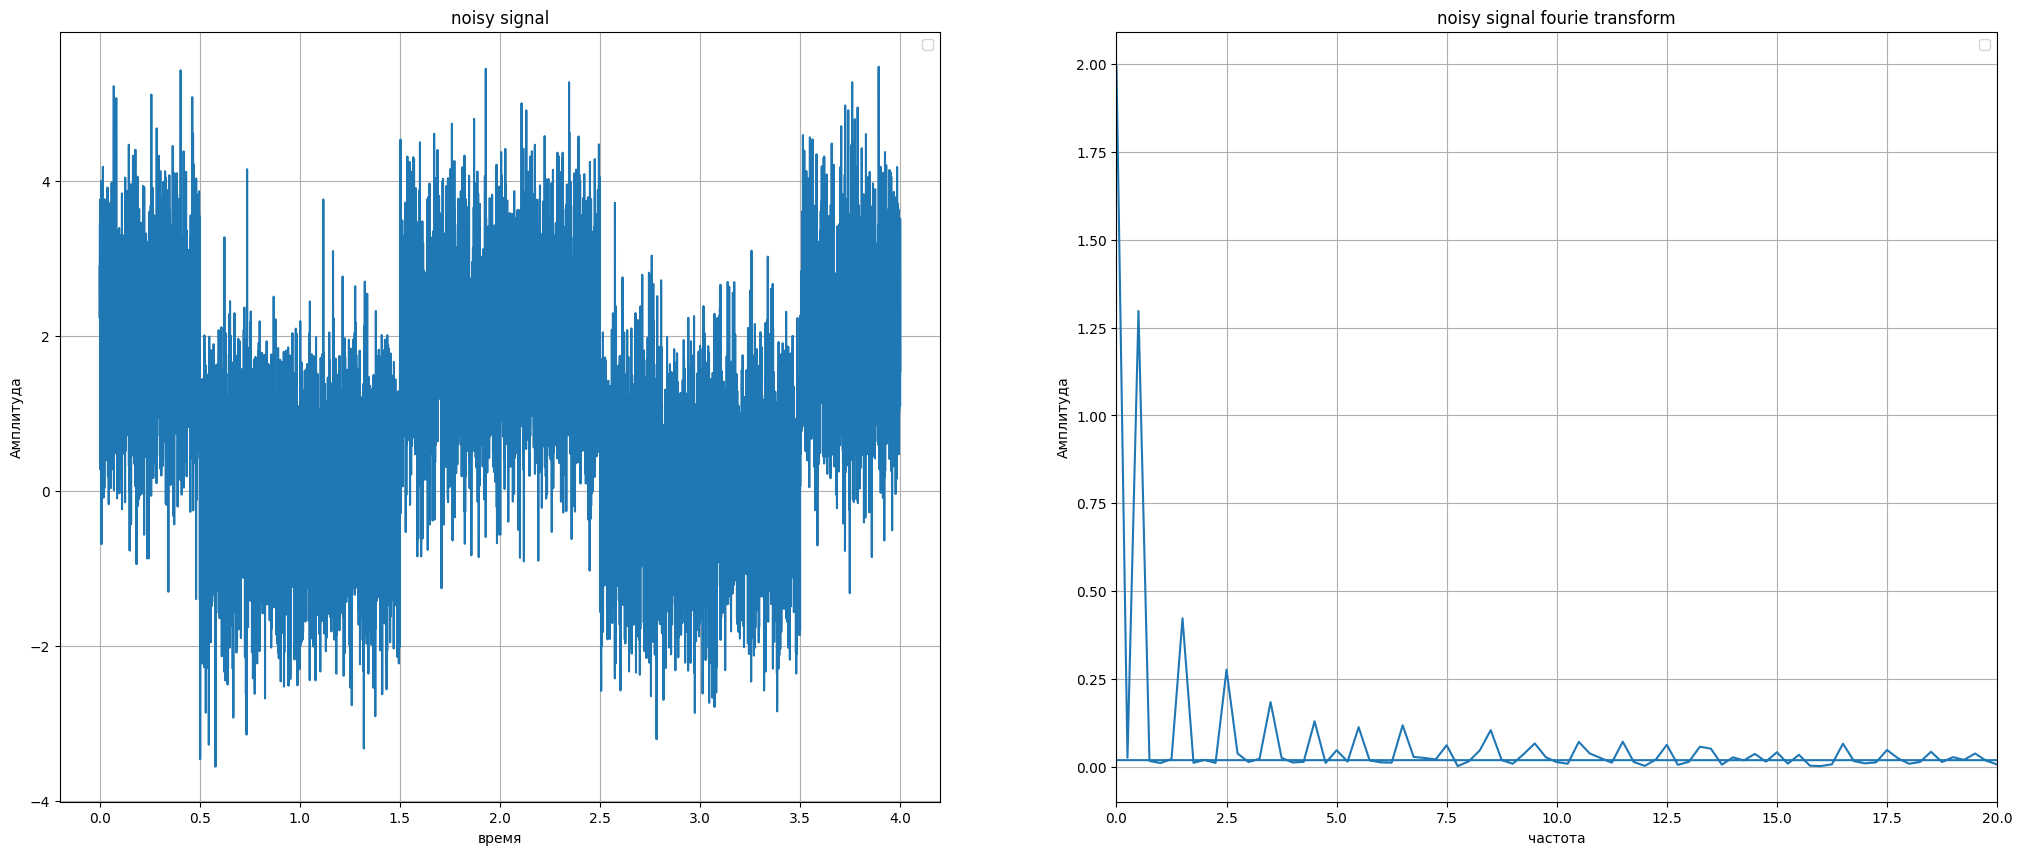

In [22]:
signal_noisy = noise(signal)

signal_noisy_fourie = np.fft.fft(signal_noisy)

bound = 20

fig, axes = plt.subplots(1, 2, figsize=(25, 10))
axes[0].plot(X, signal_noisy)
axes[0].set_title("noisy signal")
axes[0].set(ylabel="Амплитуда", xlabel="время")
# axes[0].set_xlim(-bound, bound)

axes[1].plot(freqs, abs(signal_noisy_fourie) / N * 2)
axes[1].set_title("noisy signal fourie transform")
axes[1].set(ylabel="Амплитуда", xlabel="частота")
axes[1].set_xlim(0, bound)

for axis in axes:
    axis.grid(True)
    axis.legend()

# Реализуем быстрое дискретное преобразование Фурье

In [23]:
import numpy as np

def fft_own(x):
    """
    Быстрое преобразование Фурье (рекурсивная версия, основание 2).
    
    Параметры
    ---------
    x : array_like
        Входной сигнал (может быть вещественным или комплексным).
    
    Возвращает
    -------
    numpy.ndarray
        Комплексный спектр Фурье той же длины, что и дополненный сигнал
        (ближайшая степень двойки, если исходная длина не степень 2).
    """
    x = np.asarray(x, dtype=complex)  # приводим к комплексному типу
    n = len(x)
    
    # Базовый случай
    if n == 1:
        return x
    
    # Если n не степень двойки, дополняем нулями до ближайшей степени
    if n & (n - 1) != 0:
        next_pow2 = 1 << (n.bit_length())
        x = np.pad(x, (0, next_pow2 - n), constant_values=0)
        n = next_pow2
    
    # Разделение на чётные и нечётные индексы
    even = fft_own(x[0::2])
    odd  = fft_own(x[1::2])
    
    # Поворачивающие множители (twiddle factors) для всех k сразу
    k = np.arange(n // 2)
    twiddle = np.exp(-2j * np.pi * k / n)
    
    # Объединение
    result = np.empty(n, dtype=complex)
    result[:n//2] = even + twiddle * odd
    result[n//2:] = even - twiddle * odd
    
    return result

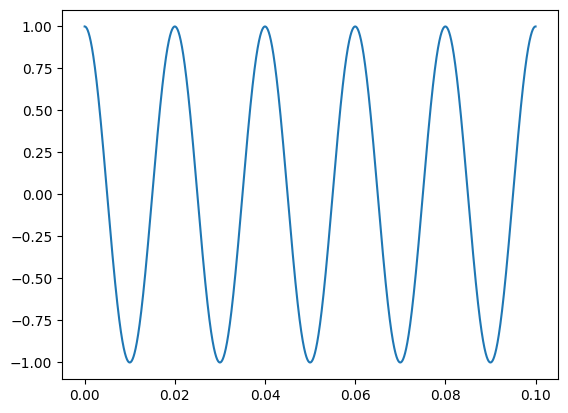

In [24]:
N = 32768
X = np.linspace(0, 1/10, N)

x_cos50 = cos_50(X)

plt.plot(X, x_cos50)

In [25]:
%timeit fft_own(x_cos50)
%timeit np.fft.fft(x_cos50)

409 ms ± 12.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.03 ms ± 43.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [34]:
dt = X[1] - X[0]
fft_own_y = fft_own(x_cos50)
fft_y = np.fft.fft(x_cos50)

freqs = np.fft.fftfreq(N, dt)
freqs_own = np.fft.fftfreq(fft_own_y.shape[0], dt)



In [27]:
X.shape

(32768,)

In [28]:
fft_y.shape

(32768,)

In [29]:
fft_own_y.shape

(32768,)

In [30]:
freqs.shape

(32768,)

In [31]:
freqs_own.shape

(32768,)

/var/folders/l5/1_g08l313298yj0kplr9hs7r0000gn/T/ipykernel_5308/3562655655.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend()


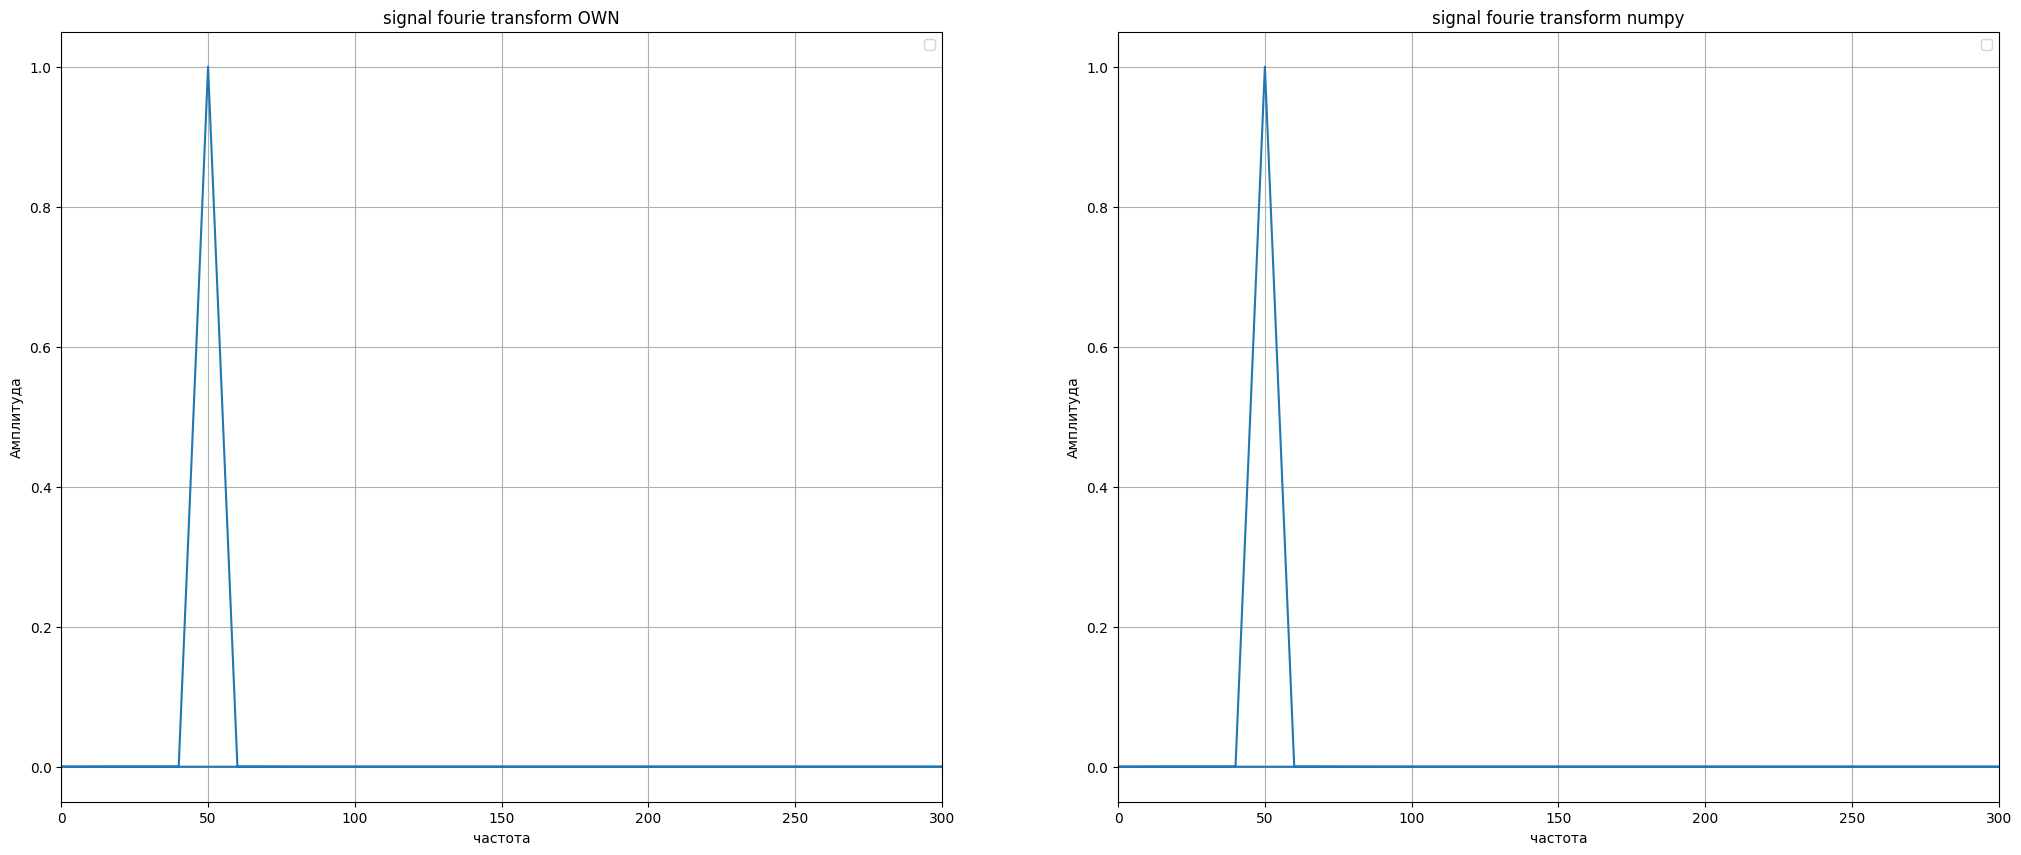

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(25, 10))
axes[0].plot(freqs, abs(fft_y) / N * 2)
axes[0].set_title("signal fourie transform OWN")
axes[0].set(ylabel="Амплитуда", xlabel="частота")
axes[0].set_xlim(0, 300)

axes[1].plot(freqs_own, abs(fft_own_y) / N * 2)
axes[1].set_title("signal fourie transform numpy")
axes[1].set(ylabel="Амплитуда", xlabel="частота")
axes[1].set_xlim(0, 300)

for axis in axes:
    axis.grid(True)
    axis.legend()